# Week 6: Decision Trees and Random Forests

## 1. Notebook Setup
- Import libraries
- Define helper functions for evaluating both classification and regression models

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

#funct for classification models
def evaluate_classification(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return {"Accuracy": acc, "Confusion Matrix": cm, "Report": report}

#funct for regression models
def evaluate_regression(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return {"MSE": mse, "R2": r2}

## 2. Dataset 1: customer_churn
### 2.1 Data Overview & Preparation

In [2]:
#load data
train_cc = pd.read_csv('customer_churn_dataset-training-master.csv')
test_cc = pd.read_csv('customer_churn_dataset-testing-master.csv')
#combine train and test set
customer_churn = pd.concat([train_cc, test_cc], ignore_index=True)
#drop null rows
customer_churn.dropna(inplace=True)

X = pd.get_dummies(customer_churn.drop("Churn", axis=1, errors="ignore"), drop_first=True)
y = customer_churn["Churn"] if "Churn" in customer_churn.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

### 2.2 Decision Tree (Classification or Regression)

In [3]:
if y is not None:
    if y.dtype == 'object' or len(y.unique()) < 10:
        dt_model = DecisionTreeClassifier(random_state=42)
        results = evaluate_classification(dt_model, X_train, X_test, y_train, y_test)
        print("Decision Tree Classifier:", results)
    else:
        dt_model = DecisionTreeRegressor(random_state=42)
        results = evaluate_regression(dt_model, X_train, X_test, y_train, y_test)
        print("Decision Tree Regressor:", results)

Decision Tree Classifier: {'Accuracy': 0.9350072247184339, 'Confusion Matrix': array([[41645,  3336],
       [ 3231, 52830]]), 'Report': '              precision    recall  f1-score   support\n\n         0.0       0.93      0.93      0.93     44981\n         1.0       0.94      0.94      0.94     56061\n\n    accuracy                           0.94    101042\n   macro avg       0.93      0.93      0.93    101042\nweighted avg       0.93      0.94      0.93    101042\n'}


### 2.3 Random Forest (Classification or Regression)

In [4]:
if y is not None:
    if y.dtype == 'object' or len(y.unique()) < 10:
        rf_model = RandomForestClassifier(random_state=42)
        results = evaluate_classification(rf_model, X_train, X_test, y_train, y_test)
        print("Random Forest Classifier:", results)
    else:
        rf_model = RandomForestRegressor(random_state=42)
        results = evaluate_regression(rf_model, X_train, X_test, y_train, y_test)
        print("Random Forest Regressor:", results)

Random Forest Classifier: {'Accuracy': 0.9360661902971041, 'Confusion Matrix': array([[41264,  3717],
       [ 2743, 53318]]), 'Report': '              precision    recall  f1-score   support\n\n         0.0       0.94      0.92      0.93     44981\n         1.0       0.93      0.95      0.94     56061\n\n    accuracy                           0.94    101042\n   macro avg       0.94      0.93      0.94    101042\nweighted avg       0.94      0.94      0.94    101042\n'}


### 2.4 Feature Importance Visualization

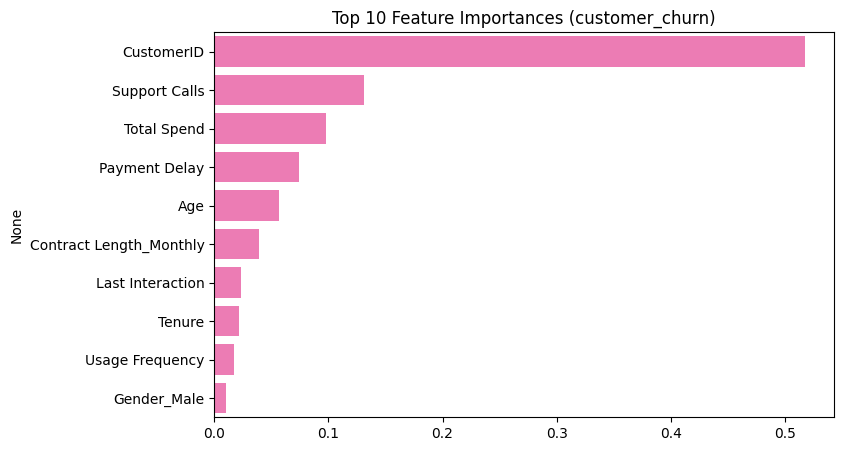

In [5]:
if y is not None:
    feature_names = X.columns
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances[indices], y=feature_names[indices], color='hotpink')
    plt.title("Top 10 Feature Importances (customer_churn)")
    plt.show()

#### Additional plots:
plot of decision-tree rules:

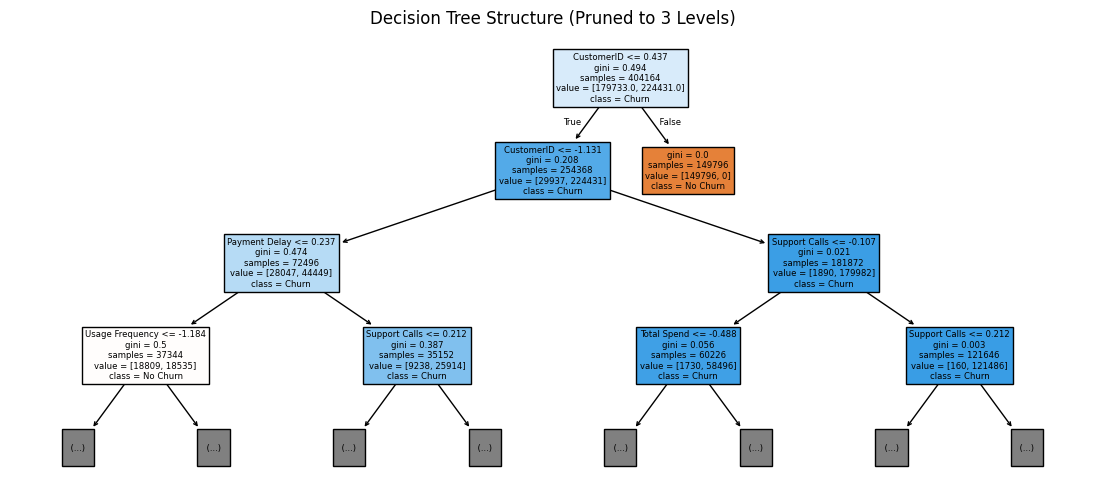

In [9]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14,6))
plot_tree(dt_model, filled=True, feature_names=X.columns, class_names=["No Churn", "Churn"], max_depth=3)
plt.title("Decision Tree Structure (Pruned to 3 Levels)")
plt.show()

plot of feature importance:

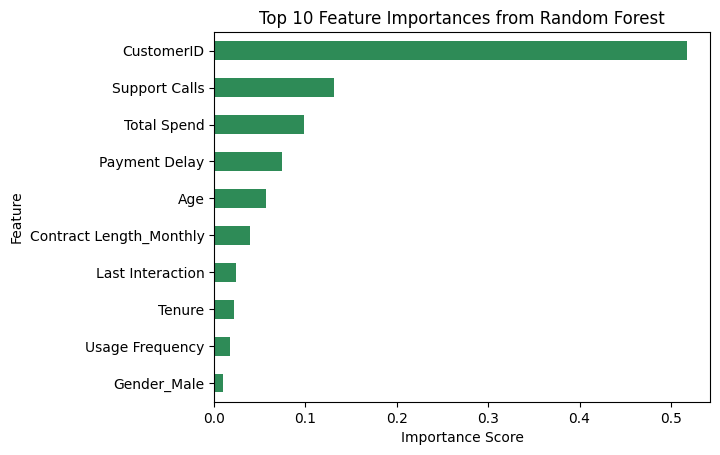

In [10]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.tail(10).plot(kind="barh", color="seagreen")
plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

## 3. Dataset 2: digital_marketing_campaign

In [11]:
digital_marketing = pd.read_csv("digital_marketing_campaign_dataset.csv")
X = pd.get_dummies(digital_marketing.drop("Conversion", axis=1, errors="ignore"), drop_first=True)
y = digital_marketing["Conversion"] if "Conversion" in digital_marketing.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

### 3.1 Decision Tree and Random Forest Models

In [12]:
if y is not None:
    if y.dtype == 'object' or len(y.unique()) < 10:
        dt = DecisionTreeClassifier(random_state=42)
        rf = RandomForestClassifier(random_state=42)
        print("Decision Tree Classifier:", evaluate_classification(dt, X_train, X_test, y_train, y_test))
        print("Random Forest Classifier:", evaluate_classification(rf, X_train, X_test, y_train, y_test))
    else:
        dt = DecisionTreeRegressor(random_state=42)
        rf = RandomForestRegressor(random_state=42)
        print("Decision Tree Regressor:", evaluate_regression(dt, X_train, X_test, y_train, y_test))
        print("Random Forest Regressor:", evaluate_regression(rf, X_train, X_test, y_train, y_test))

Decision Tree Classifier: {'Accuracy': 0.8725, 'Confusion Matrix': array([[ 105,   89],
       [ 115, 1291]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.48      0.54      0.51       194\n           1       0.94      0.92      0.93      1406\n\n    accuracy                           0.87      1600\n   macro avg       0.71      0.73      0.72      1600\nweighted avg       0.88      0.87      0.88      1600\n'}
Random Forest Classifier: {'Accuracy': 0.888125, 'Confusion Matrix': array([[  34,  160],
       [  19, 1387]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.64      0.18      0.28       194\n           1       0.90      0.99      0.94      1406\n\n    accuracy                           0.89      1600\n   macro avg       0.77      0.58      0.61      1600\nweighted avg       0.87      0.89      0.86      1600\n'}


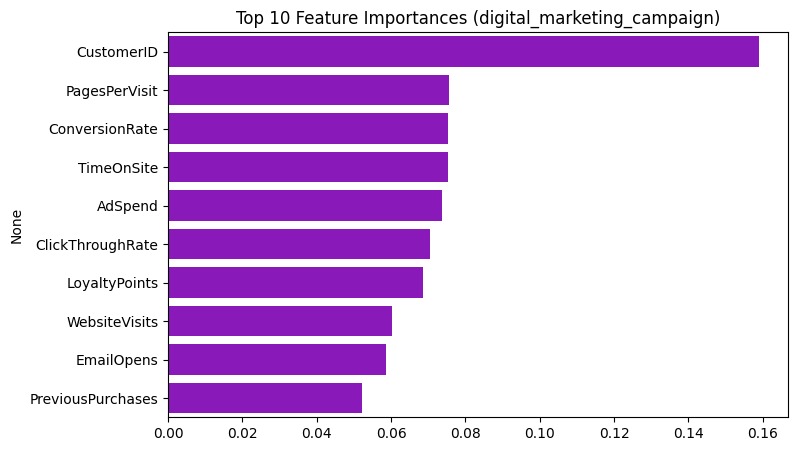

In [13]:
if y is not None:
    feature_names = X.columns
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances[indices], y=feature_names[indices], color='darkviolet')
    plt.title("Top 10 Feature Importances (digital_marketing_campaign)")
    plt.show()

## 4. Dataset 3: marketing_campaign (Optional)

In [14]:
marketing_campaign = pd.read_csv("marketing_campaign.csv", sep=';')
X = pd.get_dummies(marketing_campaign.drop("Response", axis=1, errors="ignore"), drop_first=True)
y = marketing_campaign["Response"] if "Response" in marketing_campaign.columns else None

if y is not None:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

In [15]:
if y is not None:
    if y.dtype == 'object' or len(y.unique()) < 10:
        rf = RandomForestClassifier(random_state=42)
        print("Random Forest Classifier:", evaluate_classification(rf, X_train, X_test, y_train, y_test))
    else:
        rf = RandomForestRegressor(random_state=42)
        print("Random Forest Regressor:", evaluate_regression(rf, X_train, X_test, y_train, y_test))

Random Forest Classifier: {'Accuracy': 0.8638392857142857, 'Confusion Matrix': array([[372,   7],
       [ 54,  15]]), 'Report': '              precision    recall  f1-score   support\n\n           0       0.87      0.98      0.92       379\n           1       0.68      0.22      0.33        69\n\n    accuracy                           0.86       448\n   macro avg       0.78      0.60      0.63       448\nweighted avg       0.84      0.86      0.83       448\n'}


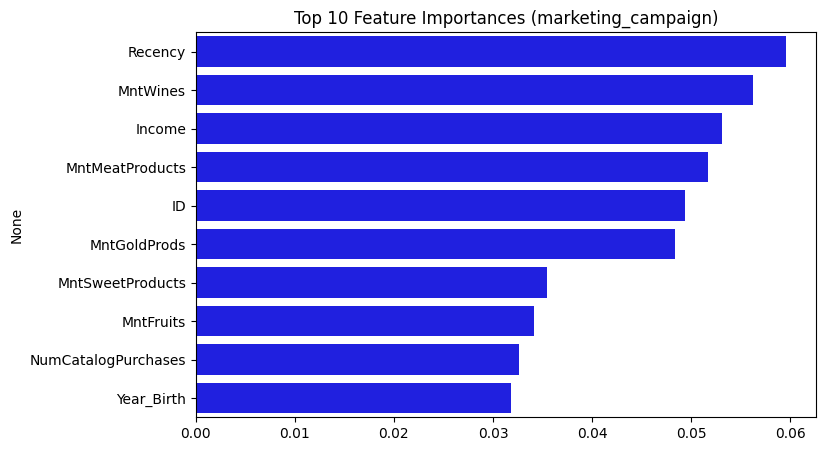

In [16]:
if y is not None:
    feature_names = X.columns
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1][:10]
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances[indices], y=feature_names[indices], color='blue')
    plt.title("Top 10 Feature Importances (marketing_campaign)")
    plt.show()